## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [1]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`.

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
```
You can use:
```
np.add(b,c,out = a) # puts result in `a`
```

In [33]:
# (re-)load layers
%run modules.ipynb

# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

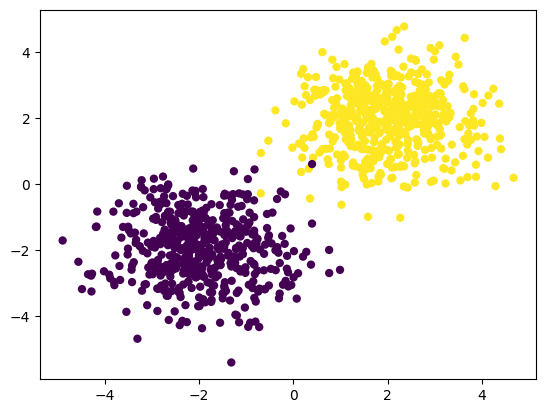

In [3]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging.

In [134]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

# Test something like that then

net = Sequential()
net.add(Linear(2, 4))
net.add(ReLU())
net.add(Linear(4, 2))
net.add(LogSoftMax())

print(net.getParameters())

Linear 2 -> 2
LogSoftMax

[[array([[ 0.4129547 , -0.15854632],
       [ 0.3365593 , -0.27656965],
       [-0.37946701, -0.06519853],
       [-0.17388225,  0.70197038]]), array([-0.25888432,  0.48069016, -0.52976521,  0.62336328])], [], [array([[-0.44203162, -0.08517805, -0.46854533, -0.49939559],
       [ 0.0070834 ,  0.06846545,  0.20866436, -0.25720288]]), array([-0.25904095,  0.20941252])], []]


Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [5]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [8]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        batch_idx = indices[start:end]

        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

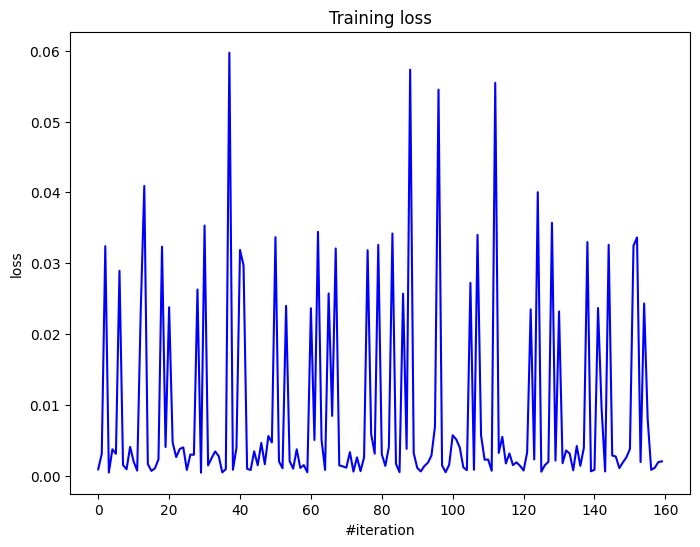

Current loss: 0.002016


In [11]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):

        net.zeroGradParameters()

        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)

        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)

        # Update weights
        sgd_momentum(net.getParameters(),
                     net.getGradParameters(),
                     optimizer_config,
                     optimizer_state)

        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss)

# Digit classification

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset. It can be downloaded with the following file.

In [12]:
!wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

--2024-12-07 16:45:42--  https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2697 (2.6K) [text/plain]
Saving to: ‘mnist.py’

mnist.py            100%[===================>]   2.63K  --.-KB/s    in 0s      

2024-12-07 16:45:43 (33.6 MB/s) - ‘mnist.py’ saved [2697/2697]



In [13]:
import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

HTTPError: HTTP Error 403: Forbidden

In [154]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

In [14]:
import numpy as np
import struct
from array import array


def read_images_labels(images_filepath, labels_filepath):
    labels = []
    with open(labels_filepath, 'rb') as file:
        magic, size = struct.unpack(">II", file.read(8))
        if magic != 2049:
            raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
        labels = array("B", file.read())

    with open(images_filepath, 'rb') as file:
        magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
        if magic != 2051:
            raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
        image_data = array("B", file.read())
    images = []
    for i in range(size):
        images.append([0] * rows * cols)
    for i in range(size):
        img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
        img = img.reshape(28, 28)
        images[i][:] = img

    return images, labels


train_images, train_labels = read_images_labels("train-images.idx3-ubyte", "train-labels.idx1-ubyte")
test_images, test_labels = read_images_labels("t10k-images.idx3-ubyte", "t10k-labels.idx1-ubyte")

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8), array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24,
       234, 254,  33,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0], dtype=uint8), array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 108,
       253, 181,   0,   0,   0,  82, 145,  53,   0,   0,   0,   0,   0,
 

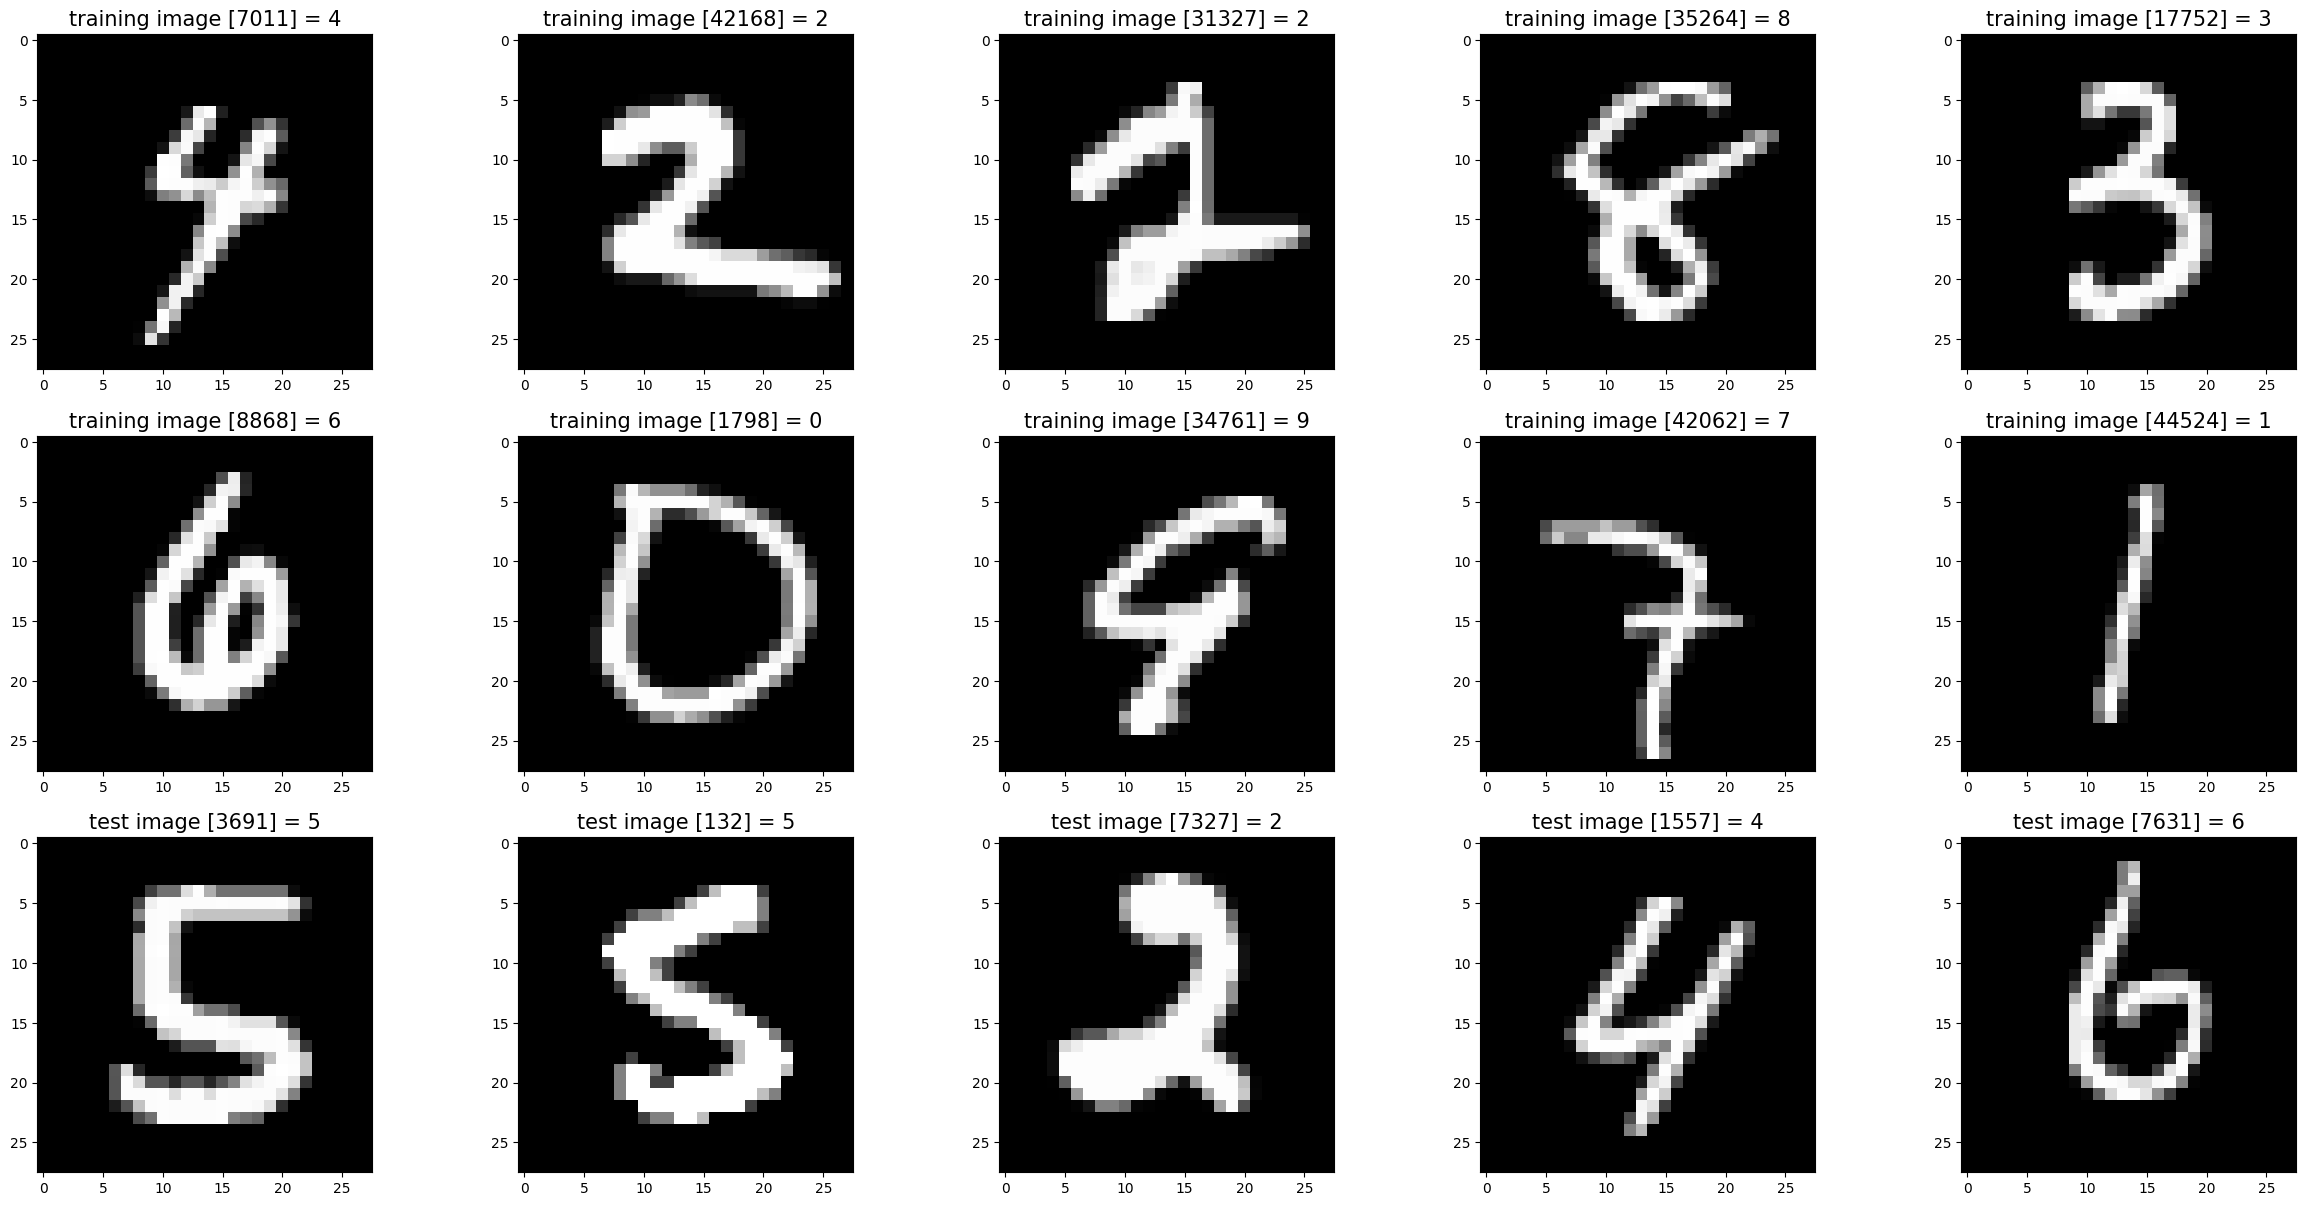

In [19]:
%matplotlib inline
import random
import matplotlib.pyplot as plt

def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);
        index += 1


images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(train_images[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(train_labels[r]))

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(test_images[r])
    titles_2_show.append('test image [' + str(r) + '] = ' + str(test_labels[r]))

show_images(images_2_show, titles_2_show)
print(images_2_show[0])
print(titles_2_show[0])

One-hot encode the labels first.

In [196]:
train_images_np = np.array(train_images)
train_labels_np = np.array(train_labels)

train_labels_mod = train_labels_np.reshape(-1, 1)
train_labels_onehot = np.eye(10)[train_labels_mod.flatten()]

- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions.
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5.

In [ ]:
# Iptimizer params
optimizer_config = {'learning_rate' : 0.01, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 10
batch_size = 2048

**ELU**

In [201]:
net = Sequential()
net.add(Flatten())
net.add(Linear(784, 128))
net.add(ELU())
net.add(Linear(128, 10))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

In [202]:
loss_history = []

for i in range(n_epoch):
  losses = []

  for x_batch, y_batch in get_batches((train_images_np, train_labels_onehot), batch_size):

      # Forward
      predictions = net.forward(x_batch)
      loss = criterion.forward(predictions, y_batch)

      # Backward
      dp = criterion.backward(predictions, y_batch)
      net.backward(x_batch, dp)

      # Update weights
      sgd_momentum(net.getParameters(),
                    net.getGradParameters(),
                    optimizer_config,
                    optimizer_state)

      net.zeroGradParameters()
      losses.append(loss)

  loss_history.append(np.mean(losses))

  # Visualize
  display.clear_output(wait=True)
  plt.figure(figsize=(8, 6))

  plt.title("Training loss")
  plt.xlabel("#iteration")
  plt.ylabel("loss")
  plt.plot(loss_history, 'b')
  plt.show()

  print('Current loss: %f' % loss_history[-1])

KeyboardInterrupt: 

In [ ]:
log_predictions_y = net.forward(np.array(test_images))

predictions_y = np.exp(log_predictions_y)

net.zeroGradParameters()

In [ ]:
test_labels_mod = np.array(test_labels).reshape(-1, 1)
test_labels_onehot = np.eye(10)[test_labels_mod.flatten()]

predictions_normalized = np.argmax(predictions_y, axis=1)

In [ ]:
print('roc_auc_score', roc_auc_score(test_labels_onehot, predictions_y))
print('accuracy_score', accuracy_score(test_labels, predictions_normalized))

roc_auc_score 0.6023081766470335
accuracy_score 0.2107


**RELU**

In [ ]:
net = Sequential()
net.add(Flatten())
net.add(Linear(784, 128))
net.add(ReLU())
net.add(Linear(128, 10))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

In [ ]:
loss_history = []

for i in range(n_epoch):
  losses = []

  for x_batch, y_batch in get_batches((train_images_np, train_labels_onehot), batch_size):

      # Forward
      predictions = net.forward(x_batch)
      loss = criterion.forward(predictions, y_batch)

      # Backward
      dp = criterion.backward(predictions, y_batch)
      net.backward(x_batch, dp)

      # Update weights
      sgd_momentum(net.getParameters(),
                    net.getGradParameters(),
                    optimizer_config,
                    optimizer_state)

      net.zeroGradParameters()
      losses.append(loss)

  loss_history.append(np.mean(losses))

  # Visualize
  display.clear_output(wait=True)
  plt.figure(figsize=(8, 6))

  plt.title("Training loss")
  plt.xlabel("#iteration")
  plt.ylabel("loss")
  plt.plot(loss_history, 'b')
  plt.show()

  print('Current loss: %f' % loss_history[-1])

KeyboardInterrupt: 

In [ ]:
log_predictions_y = net.forward(np.array(test_images))

predictions_y = np.exp(log_predictions_y)

net.zeroGradParameters()

In [ ]:
test_labels_mod = np.array(test_labels).reshape(-1, 1)
test_labels_onehot = np.eye(10)[test_labels_mod.flatten()]

predictions_normalized = np.argmax(predictions_y, axis=1)

In [ ]:
print('roc_auc_score', roc_auc_score(test_labels_onehot, predictions_y))
print('accuracy_score', accuracy_score(test_labels, predictions_normalized))

roc_auc_score 0.6023081766470335
accuracy_score 0.2107


**Leaky RelU**

In [ ]:
net = Sequential()
net.add(Flatten())
net.add(Linear(784, 128))
net.add(LeakyReLU())
net.add(Linear(128, 10))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

In [ ]:
loss_history = []

for i in range(n_epoch):
  losses = []

  for x_batch, y_batch in get_batches((train_images_np, train_labels_onehot), batch_size):

      # Forward
      predictions = net.forward(x_batch)
      loss = criterion.forward(predictions, y_batch)

      # Backward
      dp = criterion.backward(predictions, y_batch)
      net.backward(x_batch, dp)

      # Update weights
      sgd_momentum(net.getParameters(),
                    net.getGradParameters(),
                    optimizer_config,
                    optimizer_state)

      net.zeroGradParameters()
      losses.append(loss)

  loss_history.append(np.mean(losses))

  # Visualize
  display.clear_output(wait=True)
  plt.figure(figsize=(8, 6))

  plt.title("Training loss")
  plt.xlabel("#iteration")
  plt.ylabel("loss")
  plt.plot(loss_history, 'b')
  plt.show()

  print('Current loss: %f' % loss_history[-1])

KeyboardInterrupt: 

In [ ]:
log_predictions_y = net.forward(np.array(test_images))

predictions_y = np.exp(log_predictions_y)

net.zeroGradParameters()

In [ ]:
test_labels_mod = np.array(test_labels).reshape(-1, 1)
test_labels_onehot = np.eye(10)[test_labels_mod.flatten()]

predictions_normalized = np.argmax(predictions_y, axis=1)

In [ ]:
print('roc_auc_score', roc_auc_score(test_labels_onehot, predictions_y))
print('accuracy_score', accuracy_score(test_labels, predictions_normalized))

roc_auc_score 0.6023081766470335
accuracy_score 0.2107


**SoftPlus**

In [ ]:
net = Sequential()
net.add(Flatten())
net.add(SoftPlus(784, 128))
net.add(ELU())
net.add(Linear(128, 10))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

In [ ]:
loss_history = []

for i in range(n_epoch):
  losses = []

  for x_batch, y_batch in get_batches((train_images_np, train_labels_onehot), batch_size):

      # Forward
      predictions = net.forward(x_batch)
      loss = criterion.forward(predictions, y_batch)

      # Backward
      dp = criterion.backward(predictions, y_batch)
      net.backward(x_batch, dp)

      # Update weights
      sgd_momentum(net.getParameters(),
                    net.getGradParameters(),
                    optimizer_config,
                    optimizer_state)

      net.zeroGradParameters()
      losses.append(loss)

  loss_history.append(np.mean(losses))

  # Visualize
  display.clear_output(wait=True)
  plt.figure(figsize=(8, 6))

  plt.title("Training loss")
  plt.xlabel("#iteration")
  plt.ylabel("loss")
  plt.plot(loss_history, 'b')
  plt.show()

  print('Current loss: %f' % loss_history[-1])

KeyboardInterrupt: 

In [ ]:
log_predictions_y = net.forward(np.array(test_images))

predictions_y = np.exp(log_predictions_y)

net.zeroGradParameters()

In [ ]:
test_labels_mod = np.array(test_labels).reshape(-1, 1)
test_labels_onehot = np.eye(10)[test_labels_mod.flatten()]

predictions_normalized = np.argmax(predictions_y, axis=1)

In [ ]:
print('roc_auc_score', roc_auc_score(test_labels_onehot, predictions_y))
print('accuracy_score', accuracy_score(test_labels, predictions_normalized))

roc_auc_score 0.6023081766470335
accuracy_score 0.2107


**ReLU + BatchNormalization**

In [203]:
net = Sequential()
net.add(Flatten())
net.add(Linear(784, 128))
net.add(BatchNormalization())
net.add(ChannelwiseScaling(128))
net.add(ReLU())
net.add(Linear(128, 10))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

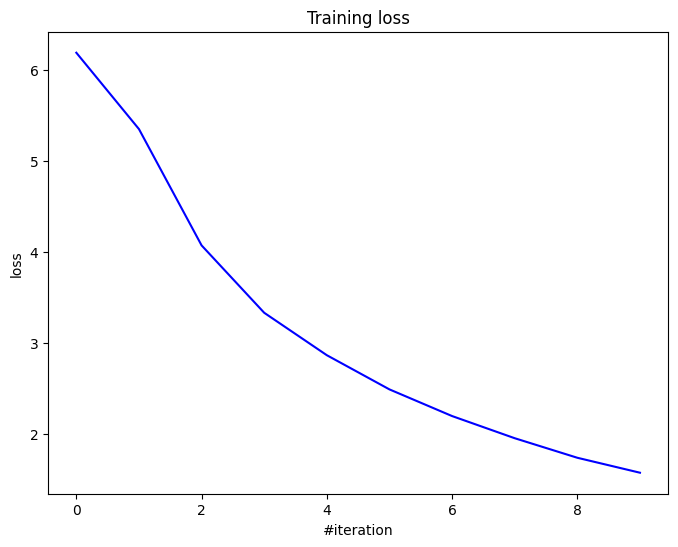

Current loss: 1.579226


In [204]:
loss_history = []

for i in range(n_epoch):
  losses = []

  for x_batch, y_batch in get_batches((train_images_np, train_labels_onehot), batch_size):

      # Forward
      predictions = net.forward(x_batch)
      loss = criterion.forward(predictions, y_batch)

      # Backward
      dp = criterion.backward(predictions, y_batch)
      net.backward(x_batch, dp)

      # Update weights
      sgd_momentum(net.getParameters(),
                    net.getGradParameters(),
                    optimizer_config,
                    optimizer_state)

      net.zeroGradParameters()
      losses.append(loss)

  loss_history.append(np.mean(losses))

  # Visualize
  display.clear_output(wait=True)
  plt.figure(figsize=(8, 6))

  plt.title("Training loss")
  plt.xlabel("#iteration")
  plt.ylabel("loss")
  plt.plot(loss_history, 'b')
  plt.show()

  print('Current loss: %f' % loss_history[-1])

In [205]:
log_predictions_y = net.forward(np.array(test_images))

predictions_y = np.exp(log_predictions_y)

net.zeroGradParameters()

In [206]:
test_labels_mod = np.array(test_labels).reshape(-1, 1)
test_labels_onehot = np.eye(10)[test_labels_mod.flatten()]

predictions_normalized = np.argmax(predictions_y, axis=1)

In [207]:
print('roc_auc_score', roc_auc_score(test_labels_onehot, predictions_y))
print('accuracy_score', accuracy_score(test_labels, predictions_normalized))

roc_auc_score 0.9687483102537158
accuracy_score 0.8752


**Relu + BatchNormalization + Adam**

In [212]:
# Iptimizer params
optimizer_config = {'learning_rate' : 0.01, 'beta1' : 0.91, 'beta2' : 0.998, 'epsilon' : 1e-08}
optimizer_state = {}

# Looping params
n_epoch = 10
batch_size = 2048

In [213]:
net = Sequential()
net.add(Flatten())
net.add(Linear(784, 128))
net.add(BatchNormalization())
net.add(ChannelwiseScaling(128))
net.add(ReLU())
net.add(Linear(128, 10))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

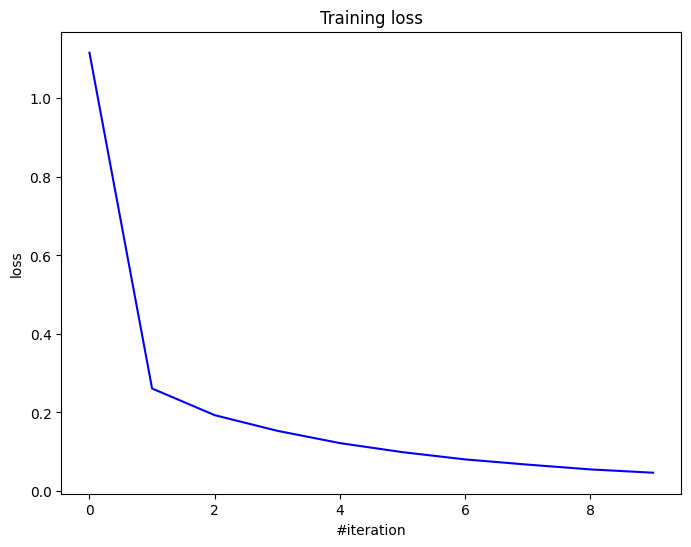

Current loss: 0.046442


In [214]:
loss_history = []

for i in range(n_epoch):
  losses = []

  for x_batch, y_batch in get_batches((train_images_np, train_labels_onehot), batch_size):

      # Forward
      predictions = net.forward(x_batch)
      loss = criterion.forward(predictions, y_batch)

      # Backward
      dp = criterion.backward(predictions, y_batch)
      net.backward(x_batch, dp)

      # Update weights
      adam_optimizer(net.getParameters(),
                    net.getGradParameters(),
                    optimizer_config,
                    optimizer_state)

      net.zeroGradParameters()
      losses.append(loss)

  loss_history.append(np.mean(losses))

  # Visualize
  display.clear_output(wait=True)
  plt.figure(figsize=(8, 6))

  plt.title("Training loss")
  plt.xlabel("#iteration")
  plt.ylabel("loss")
  plt.plot(loss_history, 'b')
  plt.show()

  print('Current loss: %f' % loss_history[-1])

In [215]:
log_predictions_y = net.forward(np.array(test_images))

predictions_y = np.exp(log_predictions_y)

net.zeroGradParameters()

In [216]:
test_labels_mod = np.array(test_labels).reshape(-1, 1)
test_labels_onehot = np.eye(10)[test_labels_mod.flatten()]

predictions_normalized = np.argmax(predictions_y, axis=1)

In [217]:
print('roc_auc_score', roc_auc_score(test_labels_onehot, predictions_y))
print('accuracy_score', accuracy_score(test_labels, predictions_normalized))

roc_auc_score 0.9993383780380816
accuracy_score 0.9735


Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

Мне кажется что использование функции активации ReLU в сочетании с Batch Normalization - лучший подход для обучения глубоких нейронных сетей. ReLU помогает ускорить обучение и улучшить общую производительность модели, в то время как Batch Normalization обеспечивает эффективную нелинейность и помогает избежать проблем умирающих градиентов. Комбинация этих двух методов обеспечивает стабильность обучения, быструю сходимость и улучшенные результаты модели в глубоком обучении.

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [ ]:
# Your code goes here. ################################################

Print here your accuracy on test set. It should be around 90%.

In [ ]:
# Your answer goes here. ################################################

### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as Fun

In [218]:
class CustomMNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_labels_tensor = torch.tensor(train_labels).type(torch.LongTensor);
train_labels_one_hot = torch.eye(10)[train_labels_tensor]
train_labels_one_hot = torch.flatten(train_labels_one_hot, start_dim=1, end_dim=2)

train_dataset = CustomMNISTDataset(images=train_images, labels=train_labels_one_hot, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [237]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.batch = nn.BatchNorm1d(128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.fc1(x)
        x = self.batch(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = nn.functional.log_softmax(x, dim=1)
        return x

In [239]:
model = NeuralNetwork()

criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10):
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, torch.argmax(labels, dim=1))
        loss.backward()
        optimizer.step()

    print(f'Epoch: {epoch+1}, Loss: {loss.item()}')


Epoch: 1, Loss: 0.13717122375965118
Epoch: 2, Loss: 0.1552615910768509
Epoch: 3, Loss: 0.026569237932562828
Epoch: 4, Loss: 0.04586485028266907
Epoch: 5, Loss: 0.07971180230379105
Epoch: 6, Loss: 0.010690503753721714
Epoch: 7, Loss: 0.050251301378011703
Epoch: 8, Loss: 0.02810055948793888
Epoch: 9, Loss: 0.040958650410175323
Epoch: 10, Loss: 0.08466009050607681


In [240]:
test_labels_tensor = torch.tensor(test_labels).type(torch.LongTensor);
test_labels_one_hot = torch.eye(10)[test_labels_tensor]

test_dataset = CustomMNISTDataset(images=test_images, labels=test_labels_one_hot, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [241]:
with torch.no_grad():
  pred_test1 = model(torch.tensor(test_images).type(torch.float32))

In [242]:
y_pred = np.argmax(pred_test1, axis=1).detach().cpu().numpy()
test_labels_np = np.array(test_labels)

test_labels_tensor = torch.tensor(test_labels).type(torch.LongTensor);
test_labels_one_hot = torch.eye(10)[test_labels_tensor]

y_pred_prob = nn.Softmax().forward(pred_test1)

/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [243]:
print('accuracy_score', accuracy_score(test_labels_np, y_pred))
print('roc_auc_score', roc_auc_score(test_labels_one_hot, y_pred_prob))

accuracy_score 0.9792
roc_auc_score 0.9995738343918941
